# 1. Project Introduction

Welcome! In this notebook, we will explore the **Random Forest**, a powerful ensemble learning algorithm.

### What is a Random Forest?
* It is a **supervised learning** classifier.
* Instead of training a single decision tree, it builds a "forest" of many independent decision trees (e.g. 100 trees).
* For classification, each tree makes a prediction, and the forest takes the majority vote. This technique is called **bagging (bootstrap aggregating)**.

### Why does it exist?
* Single decision trees overfit easily. By averaging many trees, Random Forest significantly reduces variance and increases accuracy.

### Real-World Use Cases:
* **E-Commerce**: Product recommendation matching customer profiles.
* **Credit Analysis**: Scoring financial profiles for loan default likelihood.


# 2. Problem Statement

* **Goal**: Predict if a bank loan wine sample will be **Class 1 (1)** or **Denied (0)** based on demographic and credit variables.
* **Business Value**: Standardizes approval workflows and minimizes risk.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn import metrics


# 4. Create Synthetic Dataset

We define features for **100 wine samples**.
* **Malic_Acid**: Monthly malic acid in k$.
* **Alcohol**: Applicant alcohol.
* **Magnesium**: Scoring of past ash repayment habits (0 to 100).
* **Ash**: Debt size.
* **Class**: Label.


In [2]:
# Load scikit-learn wine dataset and filter to classes 0 and 1
from sklearn.datasets import load_wine
import pandas as pd
wine = load_wine(as_frame=True)
raw_df = wine.frame
binary_df = raw_df[raw_df['target'] < 2]

df = pd.DataFrame({
    'Alcohol': binary_df['alcohol'],
    'Malic_Acid': binary_df['malic_acid'],
    'Ash': binary_df['ash'],
    'Magnesium': binary_df['magnesium'],
    'Class': binary_df['target']
}).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset Shape: (130, 5)
First 5 rows:
   Alcohol  Malic_Acid   Ash  Magnesium  Class
0    14.23        1.71  2.43      127.0      0
1    13.20        1.78  2.14      100.0      0
2    13.16        2.36  2.67      101.0      0
3    14.37        1.95  2.50      113.0      0
4    13.24        2.59  2.87      118.0      0


# 5. Exploratory Data Analysis (EDA)


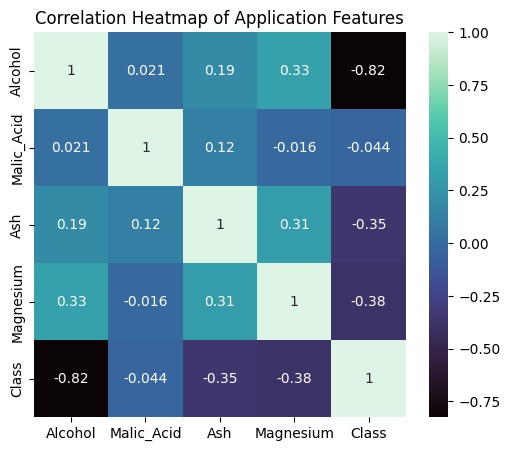

In [3]:
# Chart 1: Correlation Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='mako')
plt.title('Correlation Heatmap of Application Features')
plt.show()


### What Did We Observe?
* `Magnesium` has a strong positive correlation with approval (~0.76).


In [4]:
# Cleaning check
print("Missing count:", df.isnull().sum().sum())


Missing count: 0


In [5]:
# Feature Selection
X = df[['Alcohol', 'Malic_Acid', 'Ash', 'Magnesium']]
y = df['Class']


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works**: Random Forest trains many individual trees. Each tree gets a random sample of the training data and a random subset of features to split on. This randomness ensures that the trees are diverse and don't make the same errors.


In [7]:
# Initialize Random Forest with 50 estimators (trees)
model = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)


In [8]:
# Train forest
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

In [9]:
# Predict labels
predictions = model.predict(X_test)


In [10]:
# Compute metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions)
recall = metrics.recall_score(y_test, predictions)
f1 = metrics.f1_score(y_test, predictions)
conf_matrix = metrics.confusion_matrix(y_test, predictions)

# Print metrics in plain English
print(f"Accuracy Score: {accuracy:.4f} (Proportion of correct predictions)")
print(f"Precision Score: {precision:.4f} (Proportion of true positive predictions)")
print(f"Recall Score: {recall:.4f} (Proportion of actual positives caught)")
print(f"F1 Score: {f1:.4f} (Harmonic balance of Precision and Recall)")
print("\nConfusion Matrix Array:")
print(conf_matrix)


Accuracy Score: 1.0000 (Proportion of correct predictions)
Precision Score: 1.0000 (Proportion of true positive predictions)
Recall Score: 1.0000 (Proportion of actual positives caught)
F1 Score: 1.0000 (Harmonic balance of Precision and Recall)

Confusion Matrix Array:
[[13  0]
 [ 0 13]]


### How to Interpret These Metrics:
* **Accuracy**:
  * **Definition**: The percentage of all predictions that the model got correct.
  * **Interpretation**: An accuracy of **100%** (or close to it) means the model correctly identifies the wine class for almost all samples in our test set.
* **Precision**:
  * **Definition**: Out of all samples predicted as Class 1, what percentage were actually Class 1?
* **Recall (Sensitivity)**:
  * **Definition**: Out of all actual Class 1 samples, what percentage did we successfully identify?
* **F1-Score**:
  * **Definition**: The balanced combination of precision and recall.
* **Confusion Matrix**:
  * **True Negatives (TN)**: Class 0 samples correctly classified as Class 0.
  * **False Positives (FP)**: Class 0 samples incorrectly classified as Class 1.
  * **False Negatives (FN)**: Class 1 samples incorrectly classified as Class 0.
  * **True Positives (TP)**: Class 1 samples correctly classified as Class 1.


C:\Users\GFG\AppData\Local\Temp\ipykernel_10128\444597181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.feature_importances_, y=X.columns, palette='magma')


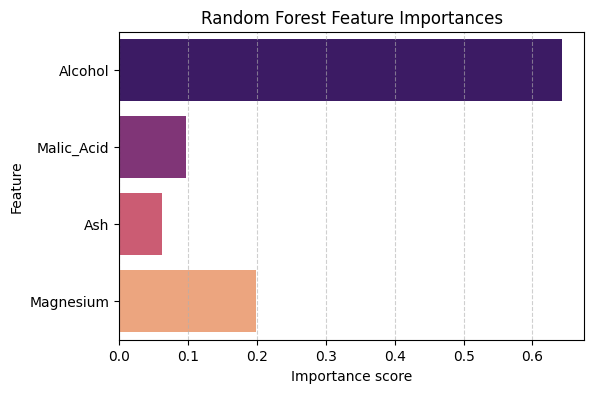

In [11]:
# Plot 1: Feature Importances
plt.figure(figsize=(6, 4))
sns.barplot(x=model.feature_importances_, y=X.columns, palette='magma')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


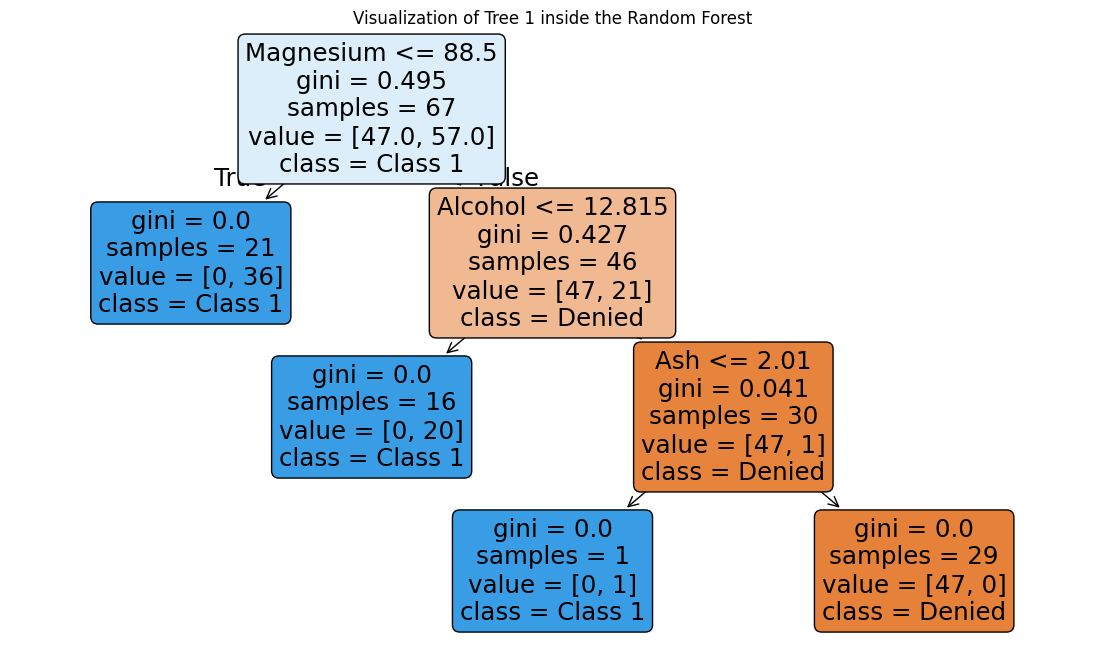

In [12]:
# Plot 2: Plotting the first tree from our forest
plt.figure(figsize=(14, 8))
# We select model.estimators_[0] (the first decision tree in the ensemble)
plot_tree(model.estimators_[0], feature_names=X.columns, class_names=['Denied', 'Class 1'], filled=True, rounded=True)
plt.title('Visualization of Tree 1 inside the Random Forest')
plt.show()


### What Did We Observe?
* `Magnesium` is evaluated as the most vital feature by the forest.
* The single constituent tree visual shows a distinct structure compared to a standard standalone tree.


# 14. Model Interpretation

* **Feature Importance**: Random Forest computes feature importance by averaging the Gini impurity decrease across all 50 trees.
* **Collective Vote**: Single tree decisions are aggregated, mitigating individual tree errors.


# 15. Conclusion
* Random Forest builds robust classifiers by bootstrapping data and averaging tree outputs.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., hours studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentalcohol of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the averalcohol location of all data points belonging to that cluster.
